# SeaClear Marine Debris — 6-Class EDA & Visualization
**Classes:** `can_metal`, `bottle_plastic`, `bottle_glass`, `net_plastic`, `bag_plastic`, `tire_rubber`  \n
Filtered from 8610 → 5720 images (kept only images with ≥1 of the 6 classes, 9120 boxes). All 6 are non-COCO exact names.
Data: `data/images/` + `data/dataset_filtered.json` (COCO-like, ids 0..5 remapped).

In [1]:
import json, random, math
from pathlib import Path
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2, numpy as np
from PIL import Image

ROOT = Path('data')
IMG_DIR = ROOT / 'images'
ANN = ROOT / 'dataset_filtered.json'
data = json.loads(ANN.read_text())
id2name = {c['id']: c['name'] for c in data['categories']}
name2id = {v:k for k,v in id2name.items()}
print(f"Images: {len(data['images'])}  Annotations: {len(data['annotations'])}  Classes: {id2name}")
img_by_id = {im['id']: im for im in data['images']}
anns_by_img = defaultdict(list)
for a in data['annotations']:
    anns_by_img[a['image_id']].append(a)

Images: 5720  Annotations: 9120  Classes: {0: 'can_metal', 1: 'bottle_plastic', 2: 'bottle_glass', 3: 'net_plastic', 4: 'bag_plastic', 5: 'tire_rubber'}


In [2]:
cnt = Counter(a['category_id'] for a in data['annotations'])
names = [id2name[i] for i in range(len(id2name))]
vals = [cnt[i] for i in range(len(id2name))]
plt.figure(figsize=(10,4))
plt.bar(names, vals, color='#0ea5e9')
plt.xticks(rotation=18)
plt.ylabel('boxes')
plt.title('Class Distribution (filtered 6, n=9120)')
for i,v in enumerate(vals):
    plt.text(i, v+40, str(v), ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print({id2name[k]: f"{v} ({v/len(data['annotations'])*100:.1f}%)" for k,v in cnt.most_common()})
per_img = [len(anns_by_img[i['id']]) for i in data['images']]
print(f"Boxes per image: mean {np.mean(per_img):.2f} median {np.median(per_img):.0f} max {max(per_img)}")
plt.figure(figsize=(6,3))
plt.hist(per_img, bins=range(1, max(per_img)+2), color='#38bdf8', edgecolor='white')
plt.xlabel('boxes / image'); plt.ylabel('images'); plt.title('Boxes per Image'); plt.show()

<Figure size 1000x400 with 1 Axes>

{'tire_rubber': '2556 (28.0%)', 'bottle_glass': '2331 (25.6%)', 'bottle_plastic': '1261 (13.8%)', 'can_metal': '1130 (12.4%)', 'net_plastic': '960 (10.5%)', 'bag_plastic': '882 (9.7%)'}
Boxes per image: mean 1.59 median 1 max 12


<Figure size 600x300 with 1 Axes>

Area: median 35621 mean 133107  median 1.72% of image
W median 210 H median 177  aspect W/H median 1.12
COCO size split: small 300 (3.3%) medium 2249 (24.7%) large 6571 (72.1%)


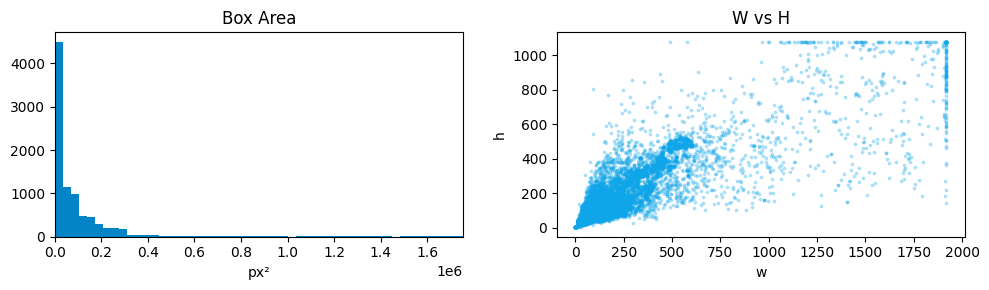

In [3]:
areas = np.array([a['area'] for a in data['annotations']])
ws = np.array([a['bbox'][2] for a in data['annotations']])
hs = np.array([a['bbox'][3] for a in data['annotations']])
img_area = 1920*1080
print(f"Area: median {np.median(areas):.0f} mean {np.mean(areas):.0f}  median {np.median(areas)/img_area*100:.2f}% of image")
print(f"W median {np.median(ws):.0f} H median {np.median(hs):.0f}  aspect W/H median {np.median(ws/hs):.2f}")
small = (areas < 32*32).sum()
medium = ((areas >= 32*32) & (areas < 96*96)).sum()
large = (areas >= 96*96).sum()
print(f"COCO size split: small {small} ({small/len(areas)*100:.1f}%) medium {medium} ({medium/len(areas)*100:.1f}%) large {large} ({large/len(areas)*100:.1f}%)")
plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.hist(areas, bins=60, color='#0284c7'); plt.xlim(0, np.percentile(areas,99)); plt.title('Box Area'); plt.xlabel('px²')
plt.subplot(1,2,2); plt.scatter(ws, hs, s=3, alpha=0.25, c='#0ea5e9'); plt.xlabel('w'); plt.ylabel('h'); plt.title('W vs H')
plt.tight_layout(); plt.show()

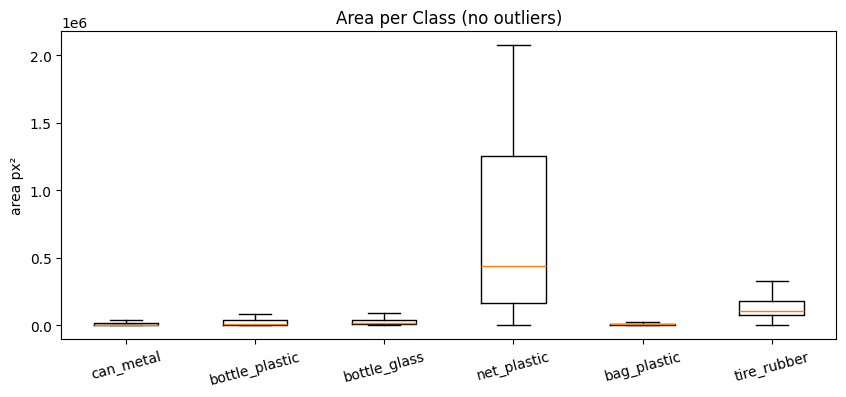

can_metal        median   5183  small% 12.3  large% 38.6
bottle_plastic   median  11096  small%  1.7  large% 54.9
bottle_glass     median  19600  small%  3.5  large% 70.2
net_plastic      median 436816  small%  0.0  large% 99.7
bag_plastic      median   8075  small%  0.1  large% 40.1
tire_rubber      median 109562  small%  2.2  large% 97.6


In [4]:
by_class_area = {i: [] for i in id2name}
for a in data['annotations']:
    by_class_area[a['category_id']].append(a['area'])
plt.figure(figsize=(10,4))
plt.boxplot([by_class_area[i] for i in range(len(id2name))], labels=names, showfliers=False)
plt.ylabel('area px²'); plt.title('Area per Class (no outliers)'); plt.xticks(rotation=15); plt.show()
for i in range(len(id2name)):
    arr = np.array(by_class_area[i])
    print(f"{id2name[i]:16s} median {np.median(arr):6.0f}  small% {(arr<1024).mean()*100:4.1f}  large% {(arr>=9216).mean()*100:4.1f}")

### Sample overlays — one row per class + random + dense


— can_metal —


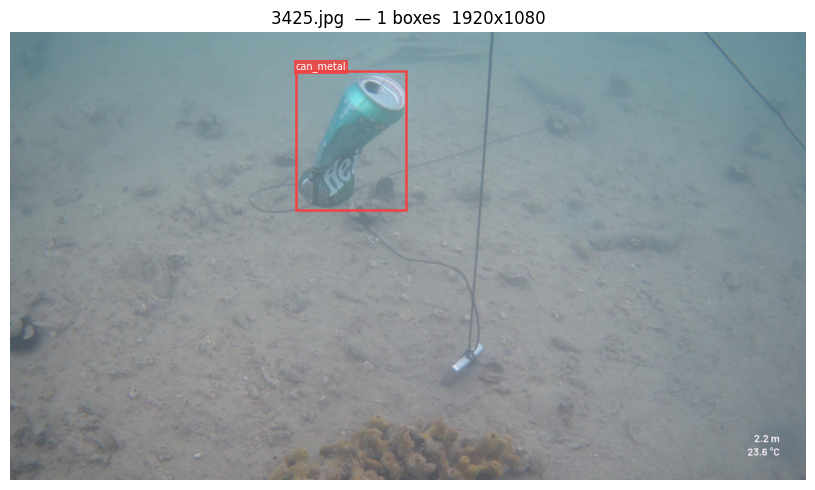

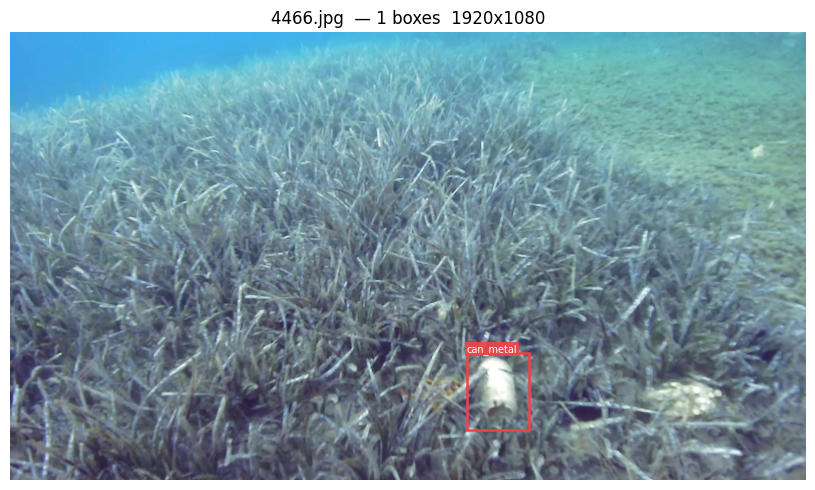


— bottle_plastic —


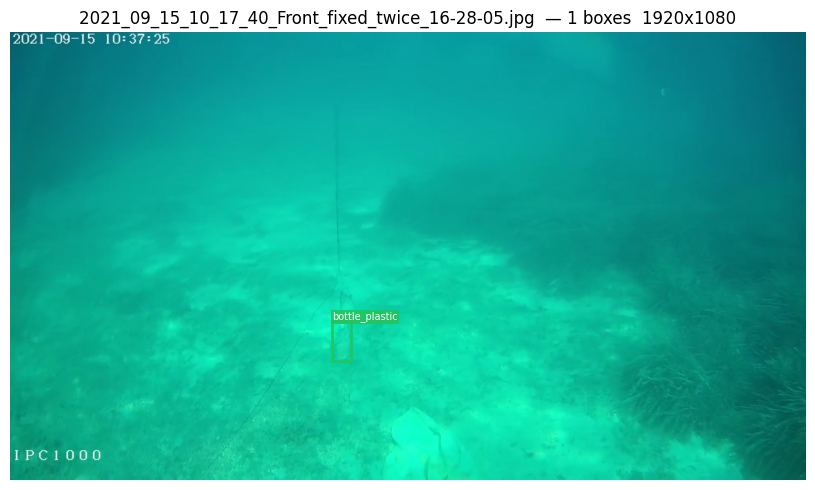

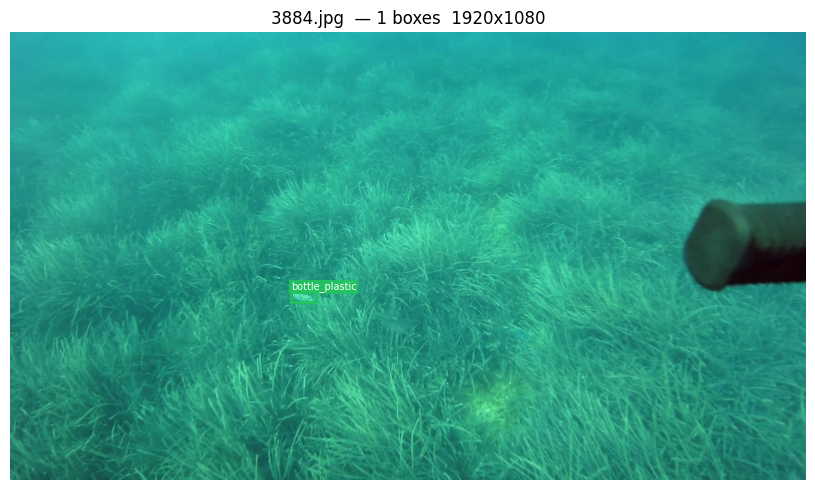


— bottle_glass —


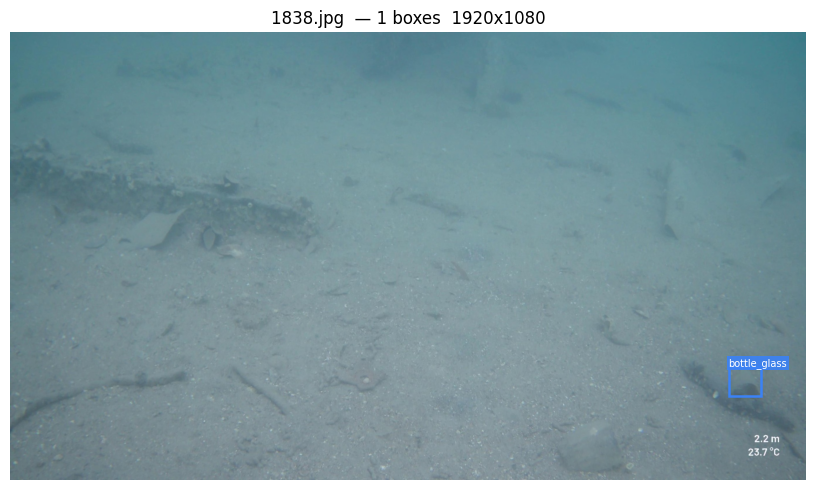

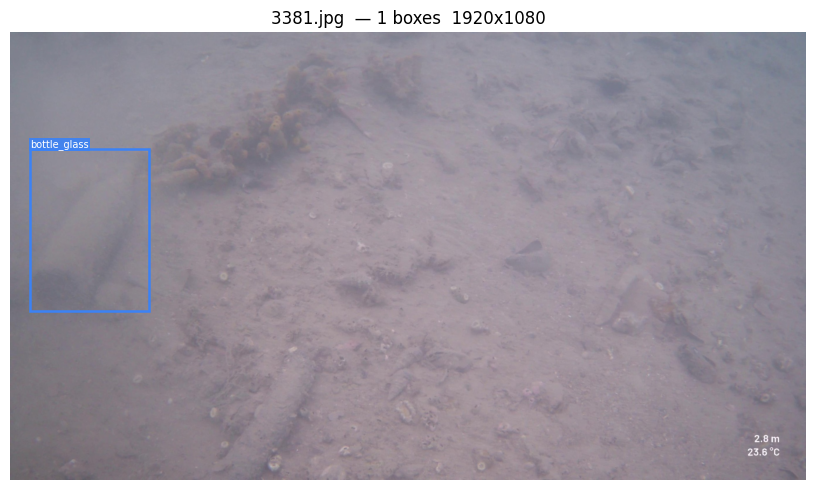


— net_plastic —


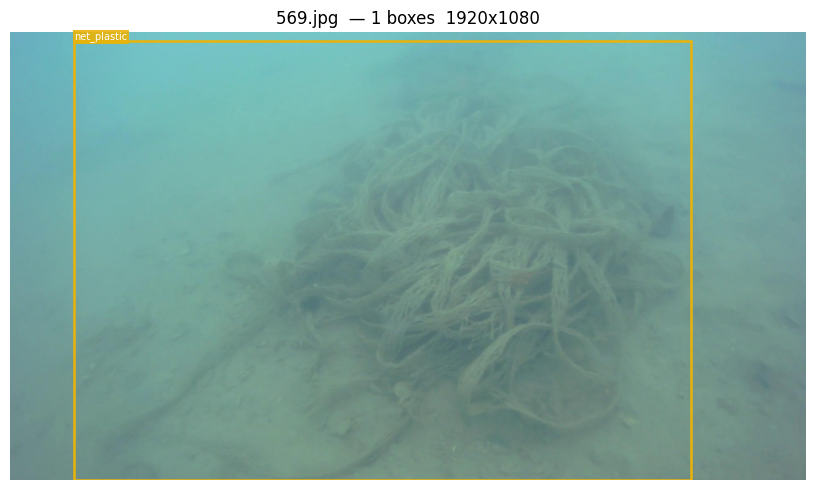

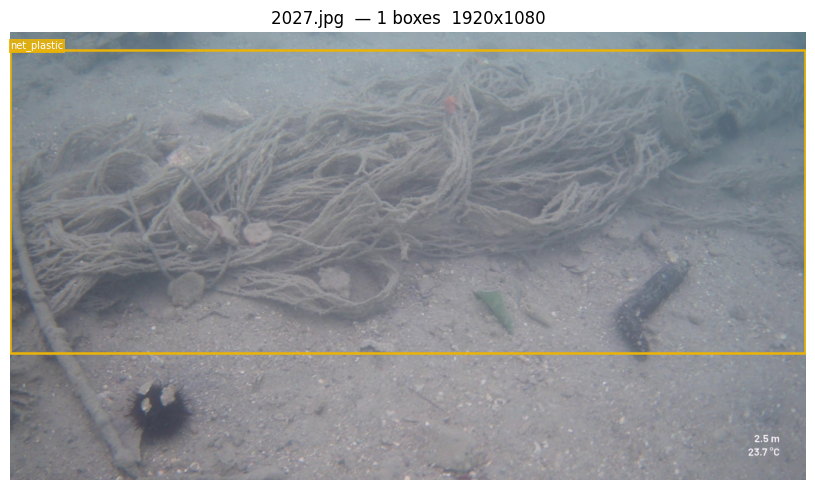


— bag_plastic —


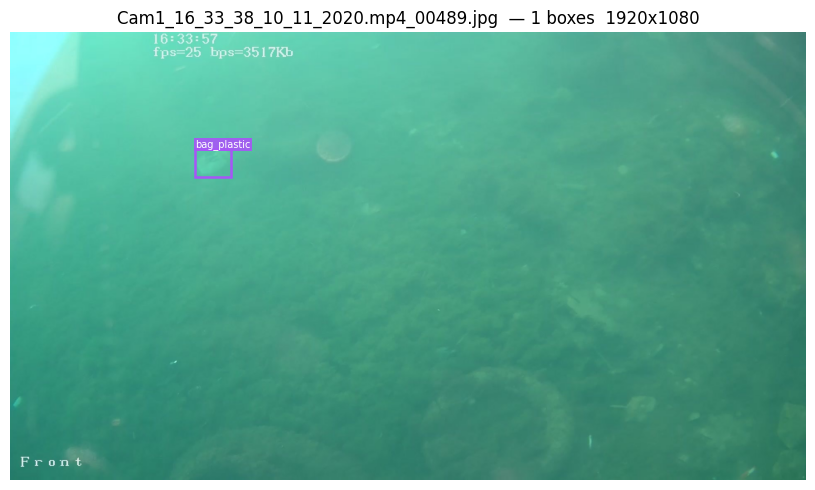

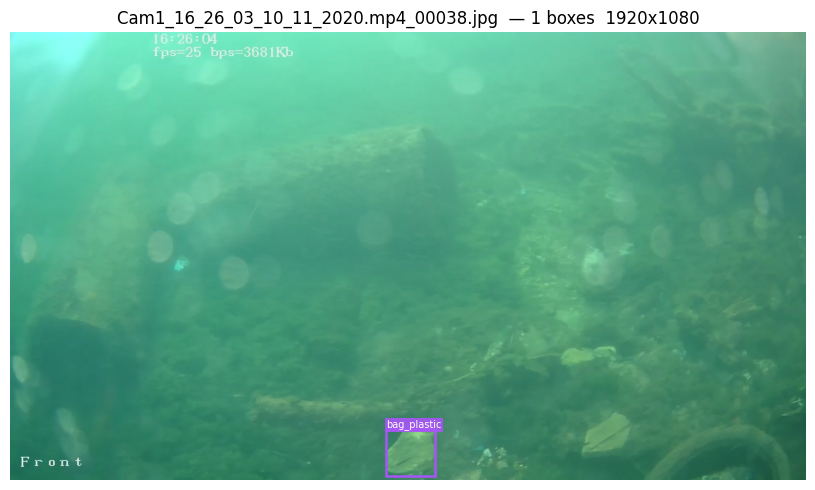


— tire_rubber —


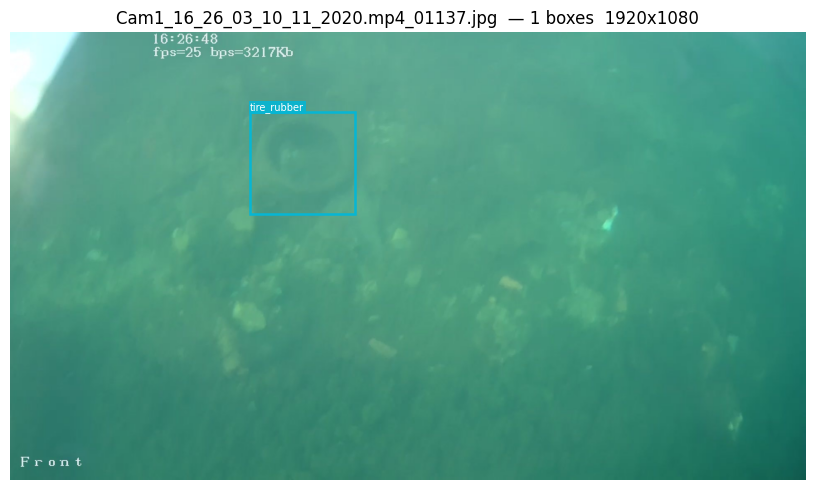

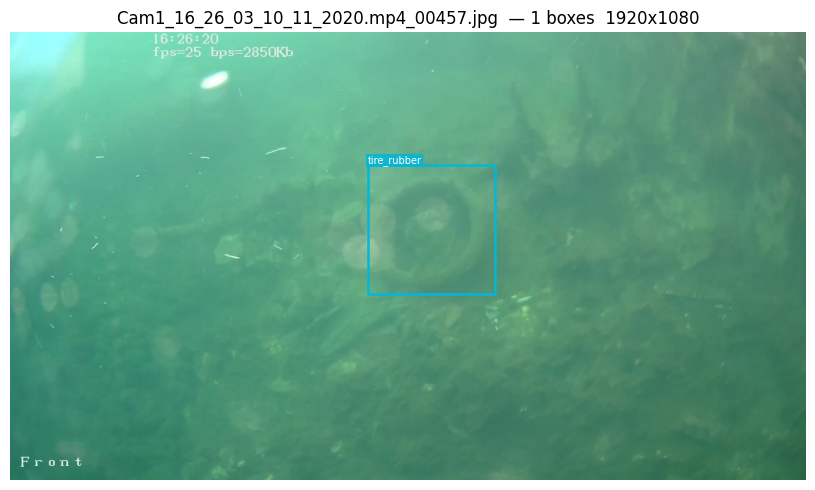

In [5]:
COLORS = ['#ef4444','#22c55e','#3b82f6','#eab308','#a855f7','#06b6d4']
def draw(img_path, anns, max_side=900):
    im = cv2.imread(str(img_path))
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    h,w = im.shape[:2]
    fig,ax = plt.subplots(1,1,figsize=(9,5))
    ax.imshow(im); ax.axis('off')
    for a in anns:
        x,y,bw,bh = a['bbox']
        cid = a['category_id']
        rect = patches.Rectangle((x,y), bw, bh, linewidth=1.8, edgecolor=COLORS[cid%len(COLORS)], facecolor='none')
        ax.add_patch(rect)
        ax.text(x, max(0,y-4), id2name[cid], fontsize=7, color='white', bbox=dict(facecolor=COLORS[cid%len(COLORS)], alpha=0.9, pad=1, edgecolor='none'))
    ax.set_title(f"{img_path.name}  — {len(anns)} boxes  {w}x{h}")
    plt.tight_layout(); plt.show()

def show_for_class(cls_name, k=2):
    cid = name2id[cls_name]
    ids = [a['image_id'] for a in data['annotations'] if a['category_id']==cid]
    # pick images with single class cleanest first
    ids = sorted(set(ids), key=lambda i: (len(anns_by_img[i])!=1, random.random()))
    for iid in ids[:k]:
        im = img_by_id[iid]
        draw(IMG_DIR / im['file_name'], anns_by_img[iid])

for n in names:
    print(f"\n— {n} —")
    show_for_class(n, k=2)

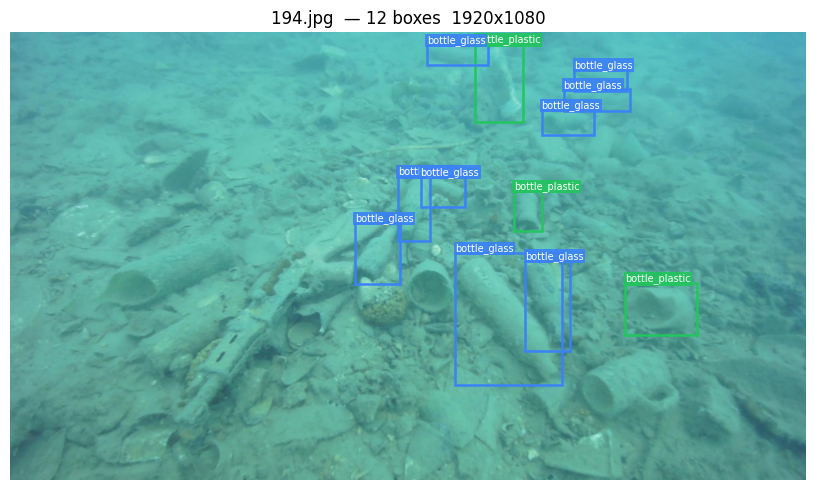

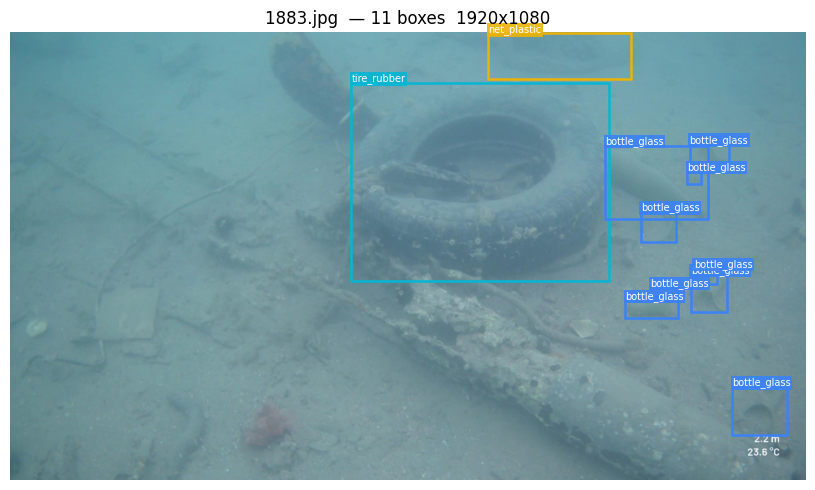

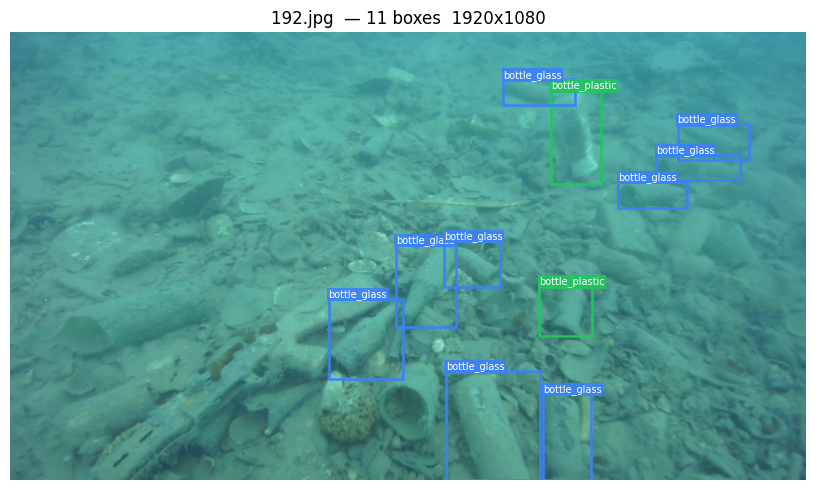

Dense counts: [12, 11, 11]


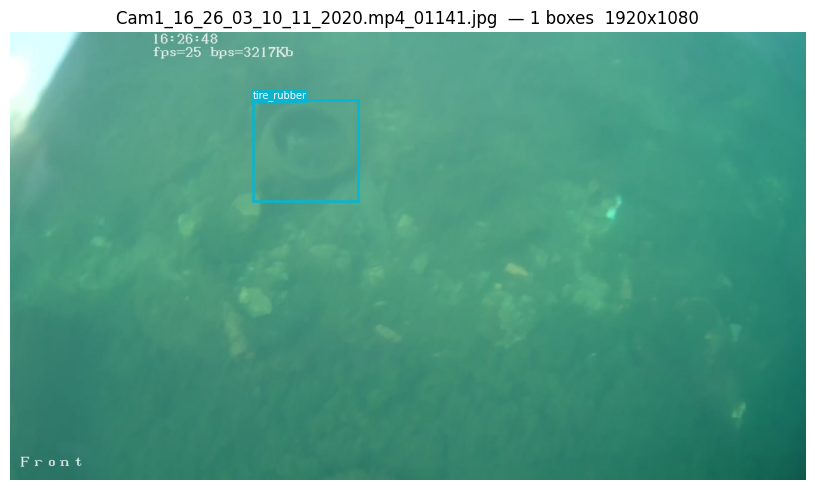

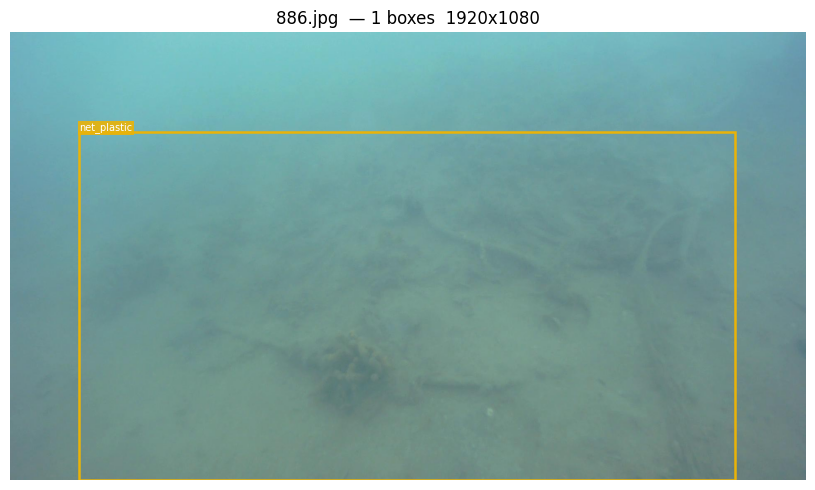

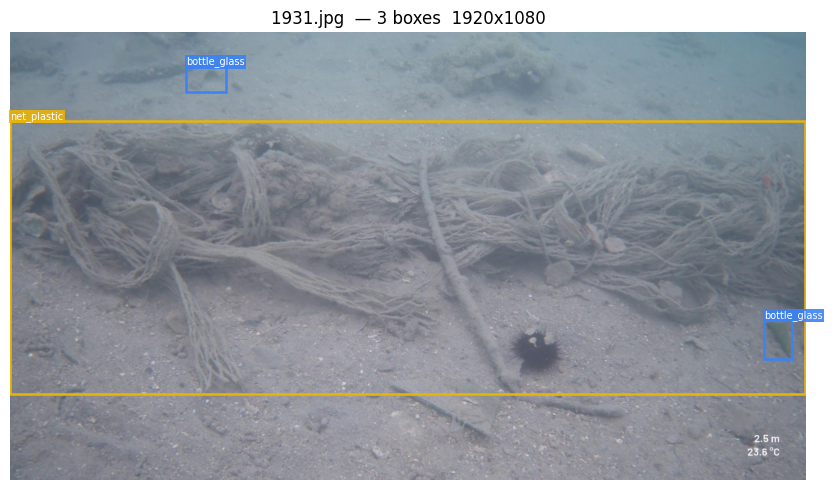

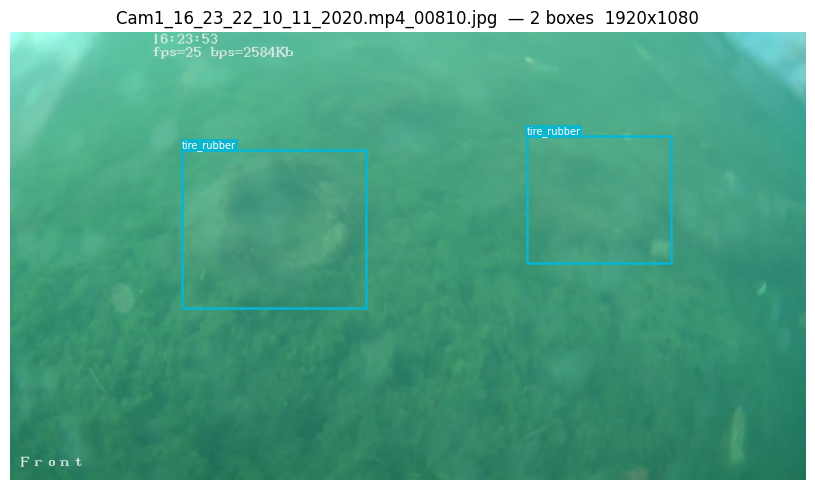

In [6]:
dense_ids = sorted(anns_by_img, key=lambda i: len(anns_by_img[i]), reverse=True)[:3]
for iid in dense_ids:
    draw(IMG_DIR / img_by_id[iid]['file_name'], anns_by_img[iid])
print('Dense counts:', [len(anns_by_img[i]) for i in dense_ids])
rand_ids = random.sample([im['id'] for im in data['images']], 4)
for iid in rand_ids:
    draw(IMG_DIR / img_by_id[iid]['file_name'], anns_by_img[iid])

### Co-occurrence & location sanity (from original zip — inferred via remaining image ids)
Shows which debris co-appear — useful for reasoning Qs like “most common”.

Top co-occurring pairs:
bottle_glass + net_plastic: 334
can_metal + bottle_plastic: 321
can_metal + bottle_glass: 304
bag_plastic + tire_rubber: 156
bottle_glass + tire_rubber: 117
bottle_plastic + net_plastic: 107
bottle_plastic + bottle_glass: 102
can_metal + net_plastic: 87
Single-category images: 4406/5720 (77.0%)


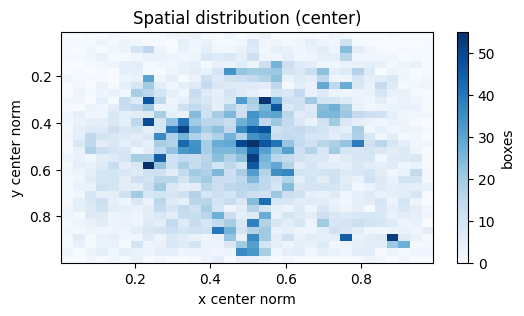

In [7]:
import itertools, pandas as pd
co = Counter()
for iid, anns in anns_by_img.items():
    cats = sorted(set(a['category_id'] for a in anns))
    if len(cats)>1:
        for a,b in itertools.combinations(cats,2):
            co[(id2name[a], id2name[b])]+=1
print('Top co-occurring pairs:')
for (a,b),c in co.most_common(8):
    print(f"{a} + {b}: {c}")
single = sum(1 for v in anns_by_img.values() if len(set(a['category_id'] for a in v))==1)
print(f"Single-category images: {single}/{len(anns_by_img)} ({single/len(anns_by_img)*100:.1f}%)")
# bbox center heatmap
xs = [(a['bbox'][0]+a['bbox'][2]/2)/1920 for a in data['annotations']]
ys = [(a['bbox'][1]+a['bbox'][3]/2)/1080 for a in data['annotations']]
plt.figure(figsize=(6,3))
plt.hist2d(xs, ys, bins=32, cmap='Blues')
plt.colorbar(label='boxes'); plt.xlabel('x center norm'); plt.ylabel('y center norm')
plt.title('Spatial distribution (center)'); plt.gca().invert_yaxis(); plt.show()

### Quick YOLO sanity (convert one image to verify)
Next pipeline step will write `data/yolo/` with `labels/*.txt` `class cx cy w h` normalized.

In [ ]:
def coco_to_yolo(bbox, W=1920, H=1080):
    x,y,w,h = bbox
    return [(x+w/2)/W, (y+h/2)/H, w/W, h/H]
sample = data['annotations'][0]
print(sample['bbox'], '->', coco_to_yolo(sample['bbox']))
print('Ready for YOLO. Run scripts/prepare_yolo.py to materialize splits.')

[983, 673, 50, 101] -> [0.525, 0.6699074074074074, 0.026041666666666668, 0.09351851851851851]
Ready for YOLO. Run scripts/prepare_yolo.py to materialize splits.


: 